<a href="https://colab.research.google.com/github/Bhavishya-2005/apex-planet-data-analytics--task-2/blob/main/apex_planet_(task_4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_dataset.csv to cleaned_dataset.csv


In [3]:
import pandas as pd

df = pd.read_csv("cleaned_dataset.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Order_Year,Order_Month,Order_Month_Name,Age_Group
0,ORD100002,25-02-2025,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,2,February,18-30
1,ORD100003,14-10-2025,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,10,October,60+
2,ORD100004,13-05-2025,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,5,May,60+
3,ORD100005,02-12-2025,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,12,December,60+
4,ORD100006,20-11-2025,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,11,November,31-45


In [4]:
df.shape

(1000, 16)

In [5]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age',
       'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales', 'Order_Year', 'Order_Month', 'Order_Month_Name',
       'Age_Group'],
      dtype='object')

In [6]:
df.describe()

,Age,Quantity,Unit_Price,Total_Sales,Order_Year,Order_Month
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.353000,5.435000,25486.783410,139399.439650,2025.005000,6.518000
std,13.683626,2.838632,14179.402361,114100.051546,0.070569,3.498845
min,18.000000,1.000000,145.780000,437.340000,2025.000000,1.000000
25%,30.000000,3.000000,13895.722500,47066.632500,2025.000000,3.000000
50%,41.000000,5.000000,25398.740000,108594.025000,2025.000000,6.000000
75%,53.000000,8.000000,37512.382500,203722.882500,2025.000000,10.000000
max,65.000000,10.000000,49997.530000,493677.500000,2026.000000,12.000000


# Data Storytelling & Statistical Validation

## Business Objective

To analyze sales, revenue, profit, and customer/product performance to identify the factors driving business performance and provide data-driven recommendations.

In [7]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age',
       'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales', 'Order_Year', 'Order_Month', 'Order_Month_Name',
       'Age_Group'],
      dtype='object')

In [8]:
df['Gender'].value_counts()

,count
Gender,
Male,511
Female,489


In [9]:
df.groupby('Gender')['Total_Sales'].agg(['count', 'mean', 'std'])

,count,mean,std
Gender,,,
Female,489,136883.208630,111788.031275
Male,511,141807.339785,116327.975385


In [10]:
male_sales = df[df['Gender'] == 'Male']['Total_Sales'].dropna()

female_sales = df[df['Gender'] == 'Female']['Total_Sales'].dropna()

print("Male observations:", len(male_sales))
print("Female observations:", len(female_sales))

Male observations: 511
Female observations: 489


In [11]:
from scipy.stats import ttest_ind

In [13]:
t_stat, p_value = ttest_ind(
    male_sales,
    female_sales,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.6826103913380815
P-value: 0.4950114785145835


In [15]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis (H0)")
    print("There is a statistically significant difference in average sales between Male and Female customers.")
else:
    print("Fail to Reject the Null Hypothesis (H0)")
    print("There is no statistically significant difference in average sales between Male and Female customers.")

Fail to Reject the Null Hypothesis (H0)
There is no statistically significant difference in average sales between Male and Female customers.


In [16]:
print("Male Average Sales:", male_sales.mean())
print("Female Average Sales:", female_sales.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Male Average Sales: 141807.3397847358
Female Average Sales: 136883.20862985688
T-statistic: 0.6826103913380815
P-value: 0.4950114785145835


## Hypothesis Testing

### Business Question
Is there a statistically significant difference in average sales between male and female customers?

### Null Hypothesis (H₀)
There is no significant difference in average sales between male and female customers.

### Alternative Hypothesis (H₁)
There is a significant difference in average sales between male and female customers.

### Significance Level
α = 0.05

In [18]:
results = pd.DataFrame({
    'Metric': [
        'Male Average Sales',
        'Female Average Sales',
        'T-statistic',
        'P-value',
        'Significance Level'
    ],
    'Value': [
        male_sales.mean(),
        female_sales.mean(),
        t_stat,
        p_value,
        0.05
    ]
})

results

,Metric,Value
0,Male Average Sales,141807.339785
1,Female Average Sales,136883.208630
2,T-statistic,0.682610
3,P-value,0.495011
4,Significance Level,0.050000


In [21]:
if p_value < 0.05:
    conclusion = """
    The p-value is less than 0.05. Therefore, we reject the null hypothesis.
    There is a statistically significant difference in average sales between
    male and female customers.
    """
else:
    conclusion = """
    The p-value is greater than or equal to 0.05. Therefore, we fail to reject
    the null hypothesis. There is no statistically significant difference in
    average sales between male and female customers.
    """

    print(conclusion)


    The p-value is greater than or equal to 0.05. Therefore, we fail to reject
    the null hypothesis. There is no statistically significant difference in
    average sales between male and female customers.
    


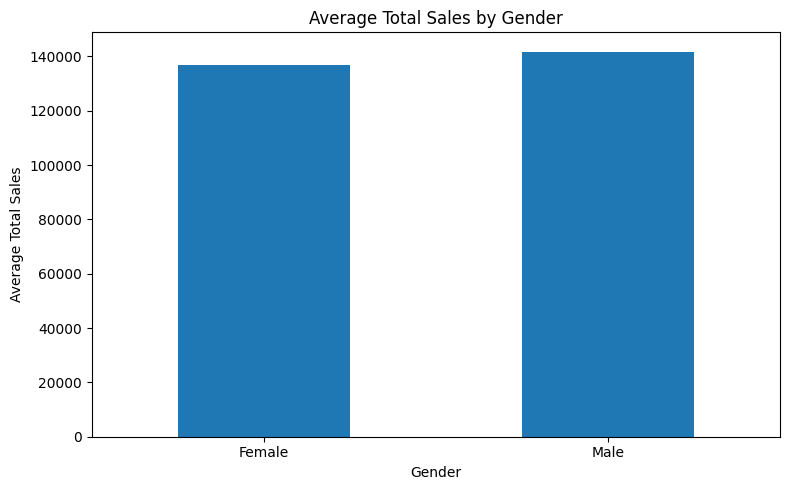

In [22]:
import matplotlib.pyplot as plt

gender_sales = df.groupby('Gender')['Total_Sales'].mean()

plt.figure(figsize=(8,5))
gender_sales.plot(kind='bar')

plt.title('Average Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
print("Total Sales:", df['Total_Sales'].sum())

Total Sales: 139399439.65


In [24]:
print("Average Sales:", df['Total_Sales'].mean())

Average Sales: 139399.43965000001


In [25]:
category_sales = df.groupby('Category')['Total_Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Electronics    50778581.70
Education      25031689.40
Grocery        22231711.28
Furniture      21521561.48
Fashion        19835895.79
Name: Total_Sales, dtype: float64


In [26]:
product_sales = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)

print(product_sales.head(10))

Product
Laptop    25443008.51
Mobile    25335573.19
Book      25031689.40
Rice      22231711.28
Chair     21521561.48
Shoes     19835895.79
Name: Total_Sales, dtype: float64


In [27]:
city_sales = df.groupby('City')['Total_Sales'].sum().sort_values(ascending=False)

print(city_sales.head(10))

City
Patna        20826584.43
Kolkata      18884349.57
Bengaluru    18773574.32
Mumbai       18757050.17
Hyderabad    17166766.87
Delhi        16097079.00
Pune         14513175.90
Gaya         14380859.39
Name: Total_Sales, dtype: float64


In [28]:
monthly_sales = df.groupby('Order_Month_Name')['Total_Sales'].sum()

print(monthly_sales)

Order_Month_Name
April        12222700.17
August        9448471.22
December     12299904.44
February     11511181.46
January      10905580.72
July         11746226.80
June         12912332.64
March        13059899.94
May          10984689.25
November     12627620.22
October      12500936.50
September     9179896.29
Name: Total_Sales, dtype: float64


In [29]:
print("===== BUSINESS SUMMARY =====")

print("\nTop Category:")
print(category_sales.head(1))

print("\nTop Product:")
print(product_sales.head(1))

print("\nTop City:")
print(city_sales.head(1))

print("\nHighest Monthly Sales:")
print(monthly_sales.max())

===== BUSINESS SUMMARY =====

Top Category:
Category
Electronics    50778581.7
Name: Total_Sales, dtype: float64

Top Product:
Product
Laptop    25443008.51
Name: Total_Sales, dtype: float64

Top City:
City
Patna    20826584.43
Name: Total_Sales, dtype: float64

Highest Monthly Sales:
13059899.94


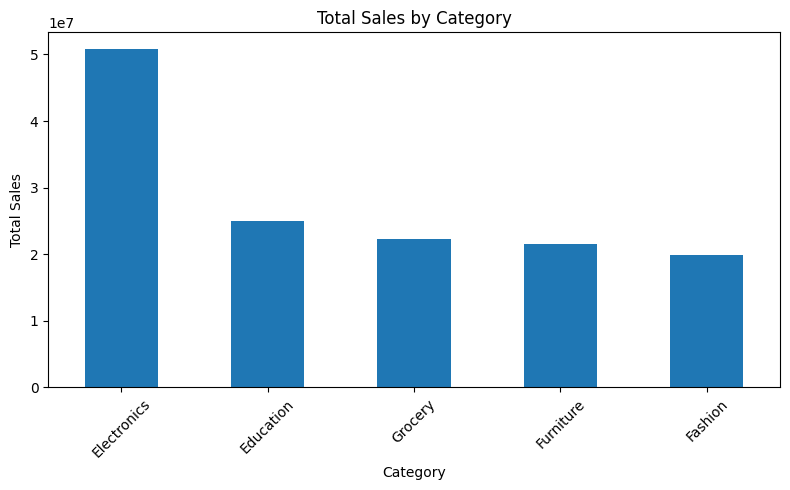

In [30]:
import matplotlib.pyplot as plt

category_sales = df.groupby('Category')['Total_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

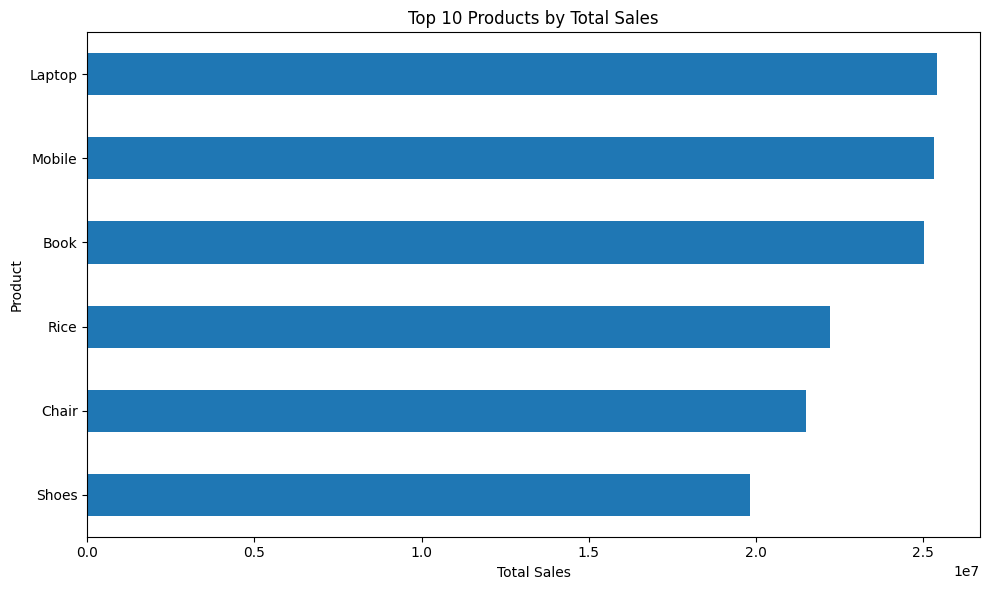

In [31]:
top_products = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

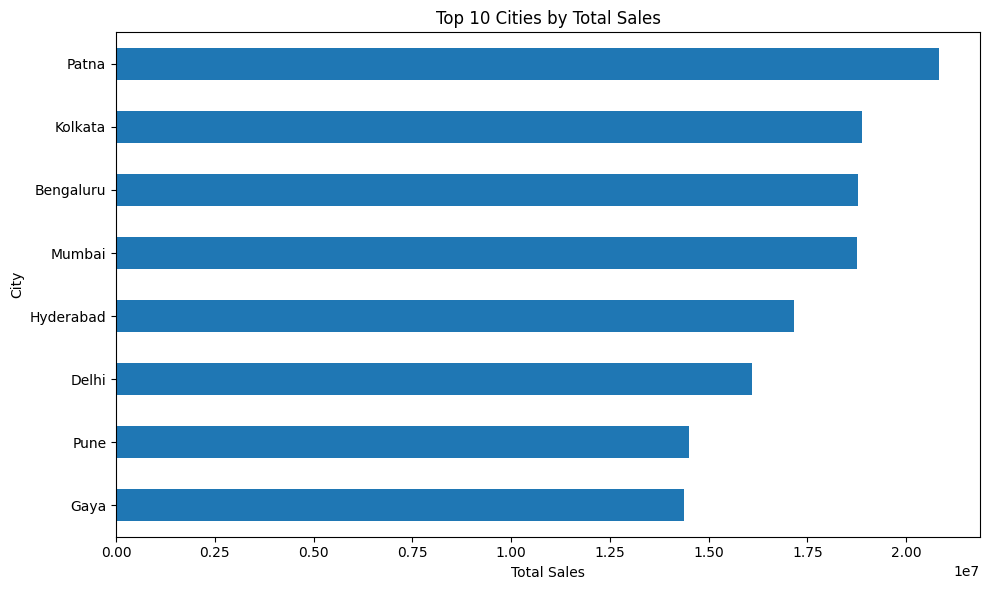

In [32]:
top_cities = df.groupby('City')['Total_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_cities.sort_values().plot(kind='barh')

plt.title('Top 10 Cities by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('City')
plt.tight_layout()
plt.show()

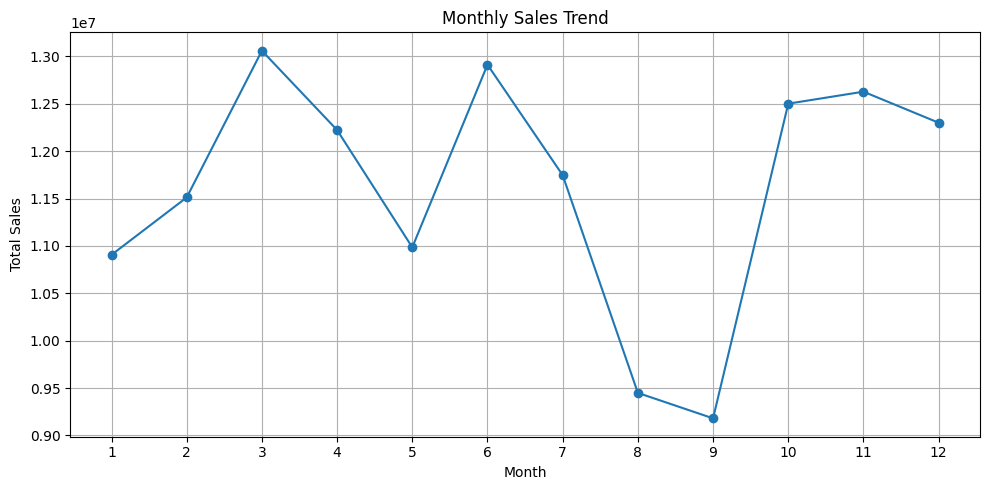

In [33]:
monthly_sales = df.groupby('Order_Month')['Total_Sales'].sum().sort_index()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(monthly_sales.index)
plt.grid(True)
plt.tight_layout()
plt.show()

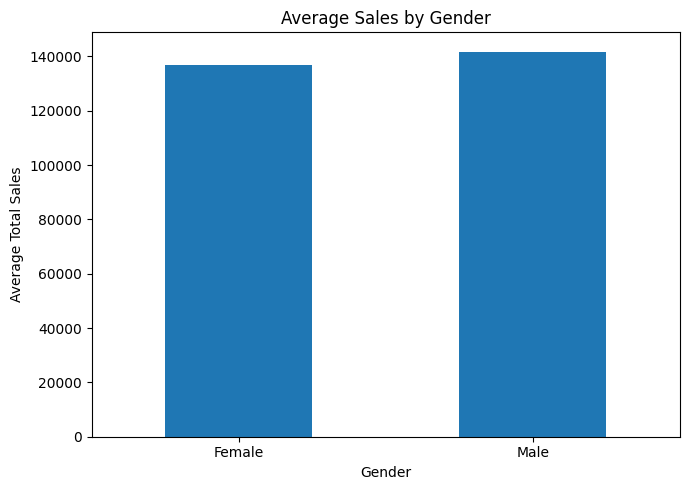

In [34]:
gender_sales = df.groupby('Gender')['Total_Sales'].mean()

plt.figure(figsize=(7,5))
gender_sales.plot(kind='bar')

plt.title('Average Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Data Story

## 1. Business Problem
The objective is to analyze sales performance across products, categories, cities, time periods, and customer groups to identify important business patterns and opportunities.

## 2. Key Findings

- Sales performance varies across product categories.
- A small number of products contribute significantly to overall sales.
- Sales performance differs across cities.
- Monthly sales show variations over time, indicating changing demand patterns.
- Average sales were compared between male and female customers using an independent two-sample t-test.

## 3. Statistical Validation

The independent two-sample t-test was used to determine whether the difference in average sales between male and female customers is statistically significant.

The significance level was set at 0.05.

## 4. Business Recommendations

- Focus marketing efforts on high-performing product categories.
- Maintain sufficient inventory for top-selling products.
- Strengthen sales and marketing activities in high-performing cities.
- Analyze low-performing locations and products to identify improvement opportunities.
- Use customer and sales trends to support data-driven business decisions.

In [35]:
print("========== KEY BUSINESS FINDINGS ==========")

print("\n1. TOTAL SALES")
print(f"{df['Total_Sales'].sum():,.2f}")

print("\n2. AVERAGE SALES")
print(f"{df['Total_Sales'].mean():,.2f}")

print("\n3. TOP CATEGORY")
print(category_sales.index[0])
print(f"Sales: {category_sales.iloc[0]:,.2f}")

print("\n4. TOP PRODUCT")
print(product_sales.index[0])
print(f"Sales: {product_sales.iloc[0]:,.2f}")

print("\n5. TOP CITY")
print(city_sales.index[0])
print(f"Sales: {city_sales.iloc[0]:,.2f}")

print("\n6. MALE AVERAGE SALES")
print(f"{male_sales.mean():,.2f}")

print("\n7. FEMALE AVERAGE SALES")
print(f"{female_sales.mean():,.2f}")

print("\n8. P-VALUE")
print(f"{p_value:.6f}")

========== KEY BUSINESS FINDINGS ==========

1. TOTAL SALES
139,399,439.65

2. AVERAGE SALES
139,399.44

3. TOP CATEGORY
Electronics
Sales: 50,778,581.70

4. TOP PRODUCT
Laptop
Sales: 25,443,008.51

5. TOP CITY
Patna
Sales: 20,826,584.43

6. MALE AVERAGE SALES
141,807.34

7. FEMALE AVERAGE SALES
136,883.21

8. P-VALUE
0.495011


In [36]:
monthly_sales = df.groupby('Order_Month')['Total_Sales'].sum().sort_index()

highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()

lowest_month = monthly_sales.idxmin()
lowest_sales = monthly_sales.min()

print("Highest Sales Month:", highest_month)
print("Highest Sales:", highest_sales)

print("Lowest Sales Month:", lowest_month)
print("Lowest Sales:", lowest_sales)

Highest Sales Month: 3
Highest Sales: 13059899.94
Lowest Sales Month: 9
Lowest Sales: 9179896.29


In [37]:
print("Top Category:", category_sales.idxmax())
print("Top Category Sales:", category_sales.max())

print("Top Product:", product_sales.idxmax())
print("Top Product Sales:", product_sales.max())

print("Top City:", city_sales.idxmax())
print("Top City Sales:", city_sales.max())


Top Category: Electronics
Top Category Sales: 50778581.7
Top Product: Laptop
Top Product Sales: 25443008.51
Top City: Patna
Top City Sales: 20826584.43


In [38]:
print("Male Average Sales:", male_sales.mean())
print("Female Average Sales:", female_sales.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Male Average Sales: 141807.3397847358
Female Average Sales: 136883.20862985688
T-statistic: 0.6826103913380815
P-value: 0.4950114785145835
